## Merton Jump Diffusion Model

The Merton Jump diffusion model is a result of Robert C. Merton's  1979 paper Option Pricing When Underlying Stock Returns Are Discountious. The main idea regarding this paper was to extend the Black-Scholes model to incorporate more realistic assumptions and that deal with the fact that empirical studies of market returns, do not follow a constant variance log-normal distribution.



## Snippet to Simulate Jump Diffusion

/Users/utsavsharma/Documents/project/Options-Pricing/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Text(0.5, 1.0, 'Jump Diffusion Process')

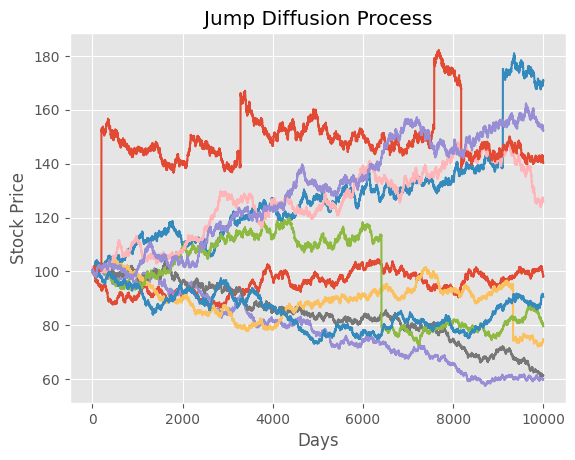

In [1]:
import requests
import math
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import norm
from scipy.optimize import minimize, minimize_scalar
from datetime import datetime as dt, timedelta as td

import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np

def merton_jump_paths(S, T, r, sigma,  lam, m, v, steps, Npaths):
    size=(steps,Npaths)
    dt = T/steps
    poi_rv = np.multiply(np.random.poisson( lam*dt, size=size),
                         np.random.normal(m,v, size=size)).cumsum(axis=0)
    geo = np.cumsum(((r -  sigma**2/2 -lam*(m  + v**2*0.5))*dt +\
                              sigma*np.sqrt(dt) * \
                              np.random.normal(size=size)), axis=0)

    return np.exp(geo+poi_rv)*S


S = 100 # current stock price
T = 1 # time to maturity
r = 0.02 # risk free rate
m = 0 # meean of jump size
v = 0.3 # standard deviation of jump
lam =1 # intensity of jump i.e. number of jumps per annum
steps =10000 # time steps
Npaths = 10 # number of paths to simulate
sigma = 0.2 # annaul standard deviation , for weiner process

j = merton_jump_paths(S, T, r, sigma, lam, m, v, steps, Npaths)

plt.plot(j)
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Jump Diffusion Process')

 Price for options that follow a jump diffusion process must always be higher than the standard Black-Scholes formula. Since we are adding randomness (which benefits the option holder), options writers should demand a larger premium for assets that follow a jump diffusion process.

Merton derived the following solution to price options that follow a jump diffusion process. The summation below takes the Black-Scholes price conditional on knowing exactly how many jumps will occur and weights these values by their corresponding probability under the Poisson distribution.

![image.png](attachment:00c793c9-eac6-4d27-b331-ace2d9f19ba0.png)
![image.png](attachment:793393cf-94f5-4e04-bac6-18838facb5ab.png)
![image.png](attachment:0212b80f-8a6b-4489-8b51-4f79f6fb9c98.png)

In [2]:
N = norm.cdf

def BS_CALL(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * N(d1) - K * np.exp(-r*T)* N(d2)

def BS_PUT(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma* np.sqrt(T)
    return K*np.exp(-r*T)*N(-d2) - S*N(-d1)


def merton_jump_call(S, K, T, r, sigma, m , v, lam):
    p = 0
    for k in range(40):
        r_k = r - lam*(m-1) + (k*np.log(m) ) / T
        sigma_k = np.sqrt( sigma**2 + (k* v** 2) / T)
        k_fact = math.factorial(k)
        p += (np.exp(-m*lam*T) * (m*lam*T)**k / (k_fact))  * BS_CALL(S, K, T, r_k, sigma_k)

    return p

def merton_jump_put(S, K, T, r, sigma, m , v, lam):
    p = 0 # price of option
    for k in range(40):
        r_k = r - lam*(m-1) + (k*np.log(m) ) / T
        sigma_k = np.sqrt( sigma**2 + (k* v** 2) / T)
        k_fact = math.factorial(k) #
        p += (np.exp(-m*lam*T) * (m*lam*T)**k / (k_fact)) \
                    * BS_PUT(S, K, T, r_k, sigma_k)
    return p

def implied_vol(opt_value, S, K, T, r, type_='call'):

    def call_obj(sigma):
        return abs(BS_CALL(S, K, T, r, sigma) - opt_value)

    def put_obj(sigma):
        return abs(BS_PUT(S, K, T, r, sigma) - opt_value)

    if type_ == 'call':
        res = minimize_scalar(call_obj, bounds=(0.01,6), method='bounded')
        return res.x
    elif type_ == 'put':
        res = minimize_scalar(put_obj, bounds=(0.01,6),
                              method='bounded')
        return res.x
    else:
        raise ValueError("type_ must be 'put' or 'call'")

## NSE Market Data Utilities

Shared utilities duplicated for Colab portability. **Canonical source:** `04_heston_model.ipynb`


In [3]:
def fetch_nse_data(symbol='NIFTY', max_retries=3):
    url = f"https://www.nseindia.com/api/option-chain-indices?symbol={symbol}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json,text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        "Referer": "https://www.nseindia.com/option-chain",
        "Connection": "keep-alive"
    }
    for attempt in range(max_retries):
        try:
            session = requests.Session()
            session.get("https://www.nseindia.com", headers=headers, timeout=10)
            time.sleep(3)
            response = session.get(url, headers=headers, timeout=10)
            data = response.json()
            return data
        except Exception as e:
            if attempt < max_retries - 1:
                print(f"Attempt {attempt+1} failed: {e}. Retrying...")
                time.sleep(5)
            else:
                raise RuntimeError(f"Failed to fetch NSE data after {max_retries} attempts: {e}")

def process_option_chain_data(data, target_expiry):
    """
    Process NSE option chain data for LTP comparison / calibration.
    Returns DataFrame with ltp_call, ltp_put, iv_call, iv_put columns.
    """
    if data is None:
        raise ValueError("No data received from NSE API")
    options_data = []
    S0 = data['records']['underlyingValue']
    for record in data['records']['data']:
        if record['expiryDate'] == target_expiry:
            strike_price = record['strikePrice']
            ltp_call = record.get('CE', {}).get('lastPrice', None)
            ltp_put  = record.get('PE', {}).get('lastPrice', None)
            iv_call  = record.get('CE', {}).get('impliedVolatility', None)
            iv_put   = record.get('PE', {}).get('impliedVolatility', None)
            options_data.append({
                'expiry_date': record['expiryDate'],
                'strike': strike_price,
                'ltp_call': ltp_call,
                'ltp_put':  ltp_put,
                'iv_call':  iv_call,
                'iv_put':   iv_put,
            })
    df = pd.DataFrame(options_data)
    if df.empty:
        raise ValueError(f"No data found for expiry date: {target_expiry}")
    print(f"Fetched {len(df)} strikes for expiry {target_expiry}. NIFTY spot: {S0}")
    return df, S0


## Applying Merton Jump Diffusion to NSE NIFTY

Using live NIFTY option chain data to price options with the Merton model.


In [4]:
# Set to a valid future NSE monthly expiry date before running
TARGET_EXPIRY = "26-Mar-2026"  # Update as needed

data = fetch_nse_data("NIFTY")
df_spot, S0 = process_option_chain_data(data, TARGET_EXPIRY)

# Compute T from target expiry
expiry_dt_nifty = dt.strptime(TARGET_EXPIRY, "%d-%b-%Y")
T_nifty = max((expiry_dt_nifty - dt.today()).days / 365, 1/365)
r_nifty = 0.06857

# Use realised vol or a default
end_date   = dt.today().strftime("%Y-%m-%d")
start_date = (dt.today() - td(days=365)).strftime("%Y-%m-%d")
import yfinance as yf
nifty_hist = yf.download("^NSEI", start_date, end_date, progress=False)
nifty_hist["daily_return"] = nifty_hist["Close"].squeeze().pct_change()
nifty_hist.dropna(inplace=True)
sigma_nifty = nifty_hist["daily_return"].std() * np.sqrt(252)
print(f"NIFTY Spot: {S0:.2f}  |  T: {T_nifty:.4f} yr  |  σ: {sigma_nifty:.4f}")

# Jump parameters (calibrated typical values for Indian markets)
m_nifty   = 1.0    # mean jump size multiplier (1 = zero mean)
v_nifty   = 0.30   # jump size std dev
lam_nifty = 0.75   # jump intensity (jumps per year)
K_atm     = round(S0 / 50) * 50  # nearest 50-point ATM strike

cf_price = merton_jump_call(S0, K_atm, T_nifty, r_nifty, sigma_nifty,
                             m_nifty, v_nifty, lam_nifty)
bs_price = BS_CALL(S0, K_atm, T_nifty, r_nifty, sigma_nifty)
print(f"ATM Strike: {K_atm}")
print(f"Merton Price : {cf_price:.2f}")
print(f"Black-Scholes: {bs_price:.2f}")
print(f"Jump Premium  : {cf_price - bs_price:.2f} (Merton > BS reflects jump risk)")


KeyError: 'records'

## Volatility Smile from Merton's Model

The following uses synthetic parameters to illustrate the IV smile shape.


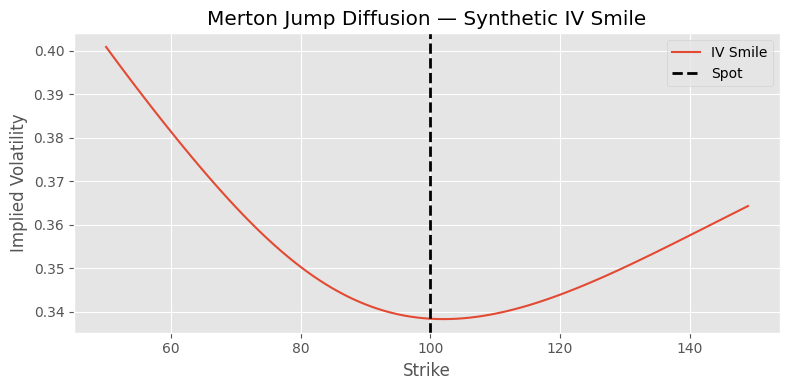

In [5]:
# ── Synthetic IV Smile (normalized parameters for shape illustration) ────
S_test      = 100
strikes_test = np.arange(50, 150, 1)
r_test      = 0.02
m_test      = 1   # m=1 means zero log-mean jump
v_test      = 0.3
lam_test    = 1
sigma_test  = 0.2
T_test      = 1

mjd_prices_test = np.array([merton_jump_call(S_test, K_i, T_test, r_test,
                             sigma_test, m_test, v_test, lam_test)
                             for K_i in strikes_test])
merton_ivs_test = [implied_vol(c, S_test, k, T_test, r_test)
                   for c, k in zip(mjd_prices_test, strikes_test)]

plt.figure(figsize=(8, 4))
plt.plot(strikes_test, merton_ivs_test, label="IV Smile")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.axvline(S_test, color="black", linestyle="dashed", linewidth=2, label="Spot")
plt.title("Merton Jump Diffusion — Synthetic IV Smile")
plt.legend()
plt.tight_layout()
plt.show()


## Model Calibration to NSE NIFTY Market Prices

Least squares calibration of the Merton Jump Diffusion model to live NSE NIFTY call option prices.
Optimizes over [σ, m, v, λ] to minimize the sum of squared pricing errors.


 least squares is used to fit the closed form solution discussed above to market data. Vmkt is the price of the option observed in the market.

![image.png](attachment:93b901cc-581e-461a-bb0a-f9ae94f8693b.png)
m represents the average jump size as a multiple of the stock price.

In [6]:
# ── Calibration to NSE NIFTY Market Data ────────────────────────────────────
# Set to a valid future NSE monthly expiry date before running
TARGET_EXPIRY = "26-Mar-2026"  # Update as needed

data = fetch_nse_data("NIFTY")
df_nse, S0_nse = process_option_chain_data(data, TARGET_EXPIRY)

# Compute T from target expiry
expiry_dt = dt.strptime(TARGET_EXPIRY, "%d-%b-%Y")
T_nse = max((expiry_dt - dt.today()).days / 365, 1/365)

# Filter near-the-money call options (±10% from spot) with valid LTP
df_calib = df_nse[(df_nse["strike"] >= S0_nse * 0.9) &
                  (df_nse["strike"] <= S0_nse * 1.1) &
                  (df_nse["ltp_call"].notna()) &
                  (df_nse["ltp_call"] > 0)].copy()

print(f"Calibrating over {len(df_calib)} near-the-money call strikes")
print(df_calib[["strike", "ltp_call", "iv_call"]].head(10))


KeyError: 'records'

The NIFTY option chain data includes:
- **Strike Price** — Option strike in INR
- **LTP (Last Traded Price)** — Most recent transaction price
- **Implied Volatility** — Market-implied IV extracted from NSE
- **Maturity** — Time to expiry in years (computed from TARGET_EXPIRY)


We are using an initial guess for σ = 0.15, m = 1, v = 0.10 and λ=1


In [7]:
def optimal_params_nse(x, df, S0, T, r):
    """Calibration objective: sum of squared errors between Merton and market prices."""
    sigma_c, m_c, v_c, lam_c = x
    try:
        candidate_prices = np.array([
            merton_jump_call(S0, K_i, T, r, sigma_c, m_c, v_c, lam_c)
            for K_i in df["strike"].values
        ])
        return np.linalg.norm(df["ltp_call"].values - candidate_prices, 2)
    except Exception:
        return 1e10

r_calib = 0.06857
x0     = [0.15, 1.0, 0.10, 0.75]
bounds = ((0.01, 2.0), (0.01, 2.0), (1e-5, 2.0), (0.0, 10.0))

res = minimize(optimal_params_nse, method='SLSQP', x0=x0,
               args=(df_calib, S0_nse, T_nse, r_calib),
               bounds=bounds, tol=1e-12,
               options={"maxiter": 1000})

sigt, mt, vt, lamt = res.x
print(f"\nCalibration success: {res.success}")
print(f"Calibrated Volatility (σ) : {sigt:.4f}")
print(f"Calibrated Jump Mean  (m) : {mt:.4f}")
print(f"Calibrated Jump Std   (v) : {vt:.4f}")
print(f"Calibrated Intensity  (λ) : {lamt:.4f}")


NameError: name 'df_calib' is not defined

In [8]:
# Plot calibrated Merton prices vs market prices (NSE NIFTY)
df_calib["merton_fitted"] = [
    merton_jump_call(S0_nse, K_i, T_nse, r_calib, sigt, mt, vt, lamt)
    for K_i in df_calib["strike"].values
]

plt.figure(figsize=(10, 5))
plt.scatter(df_calib["strike"], df_calib["ltp_call"], label="Market Prices (LTP)", color="steelblue")
plt.plot(df_calib["strike"], df_calib["merton_fitted"], color="black", label="Merton Model Fitted")
plt.axvline(S0_nse, color="grey", linestyle="--", label=f"Spot ({S0_nse:.0f})")
plt.xlabel("Strike Price (INR)")
plt.ylabel("Call Option Price (INR)")
plt.title("Merton Jump Diffusion — Calibrated to NSE NIFTY")
plt.legend()
plt.tight_layout()
plt.show()

# SS Residuals
ss_res = np.sum((df_calib["ltp_call"].values - df_calib["merton_fitted"].values) ** 2)
ss_tot = np.sum((df_calib["ltp_call"].values - df_calib["ltp_call"].mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"\nR² (goodness of fit): {r2:.4f}")


NameError: name 'df_calib' is not defined